In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [2]:
x,y_true=make_blobs(n_samples=800,
                    centers=8,
                    cluster_std=1.2,
                    random_state=7)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x=scaler.fit_transform(x)

k =  2 | WCSS =   883.58 | Silhouette = 0.4740 | Davies-Bouldin = 1.0253 | Calinski-Harabasz = 647.03
k =  3 | WCSS =   356.39 | Silhouette = 0.5872 | Davies-Bouldin = 0.6024 | Calinski-Harabasz = 1390.55
k =  4 | WCSS =   241.99 | Silhouette = 0.5540 | Davies-Bouldin = 0.6324 | Calinski-Harabasz = 1488.98
k =  5 | WCSS =   152.70 | Silhouette = 0.5727 | Davies-Bouldin = 0.6115 | Calinski-Harabasz = 1883.90
k =  6 | WCSS =   105.11 | Silhouette = 0.5919 | Davies-Bouldin = 0.5829 | Calinski-Harabasz = 2258.77
k =  7 | WCSS =    75.18 | Silhouette = 0.6202 | Davies-Bouldin = 0.5146 | Calinski-Harabasz = 2680.58
k =  8 | WCSS =    62.96 | Silhouette = 0.5452 | Davies-Bouldin = 0.6350 | Calinski-Harabasz = 2761.94
k =  9 | WCSS =    58.86 | Silhouette = 0.5092 | Davies-Bouldin = 0.7382 | Calinski-Harabasz = 2589.16
k = 10 | WCSS =    55.42 | Silhouette = 0.4688 | Davies-Bouldin = 0.8402 | Calinski-Harabasz = 2446.99
k = 11 | WCSS =    52.22 | Silhouette = 0.4483 | Davies-Bouldin = 0.8661 |

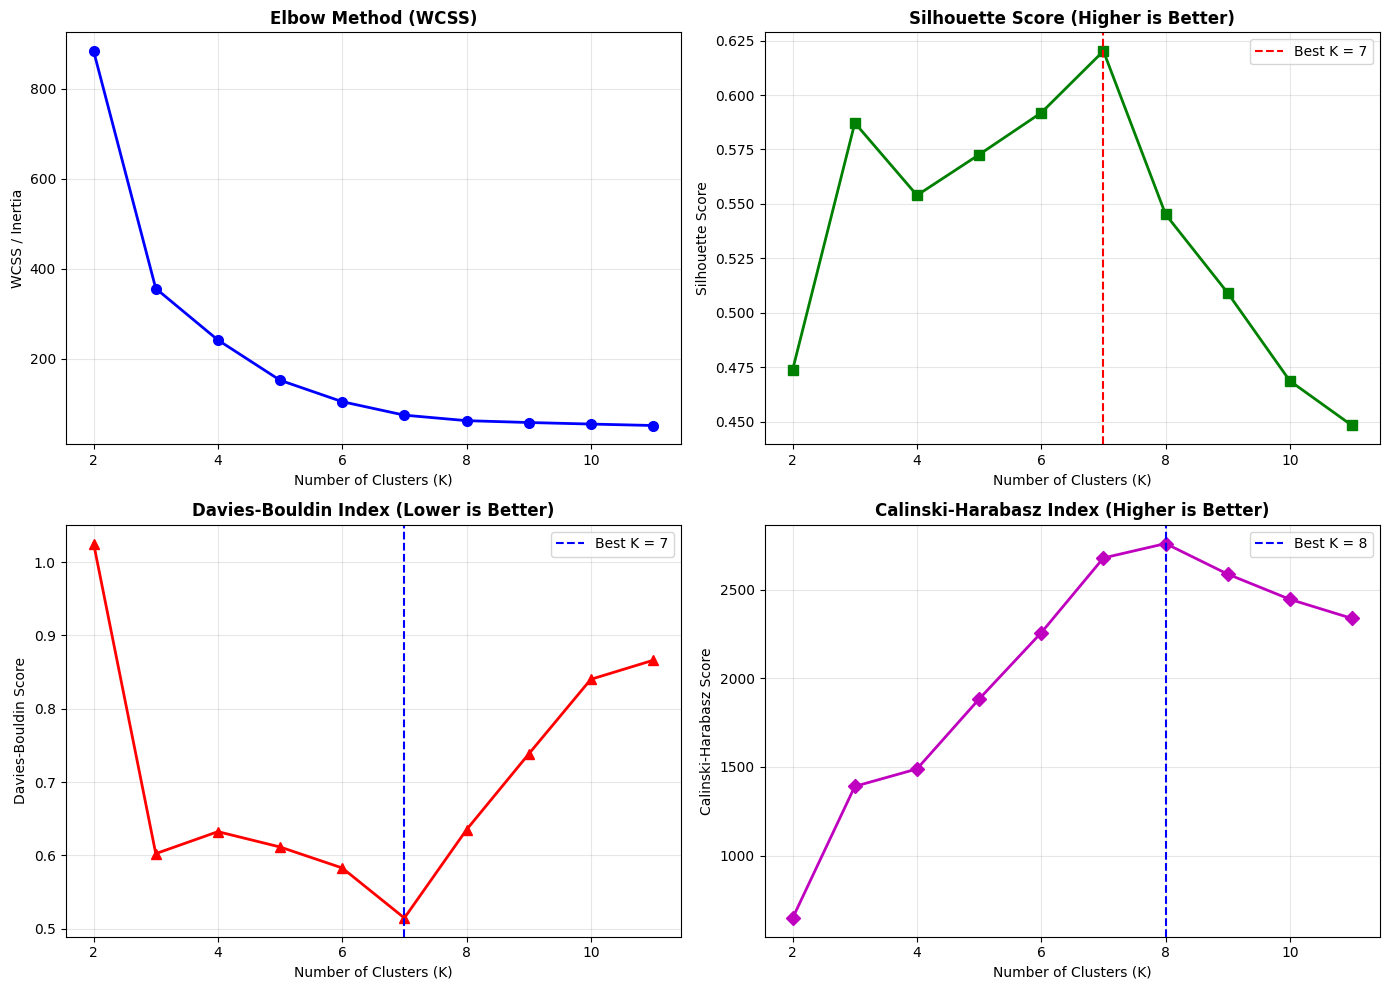

In [9]:
K_range=range(2,12) ##K=10 dows not form a clear elbow.
wcss,sil_scores,db_scores,ch_scores=[],[],[],[]
for k in K_range:
  km=KMeans(n_clusters=k,
            init="k-means++",
            n_init=10,
            random_state=42)
  labels=km.fit_predict(x)
  wcss.append(km.inertia_)
  sil_scores.append(silhouette_score(x,labels))
  db_scores.append(davies_bouldin_score(x,labels))
  ch_scores.append(calinski_harabasz_score(x,labels))

  print(
        f"k = {k:2d} | WCSS = {km.inertia_:8.2f} | "
        f"Silhouette = {sil_scores[-1]:.4f} | "
        f"Davies-Bouldin = {db_scores[-1]:.4f} | "
        f"Calinski-Harabasz = {ch_scores[-1]:.2f}"
    )

K_list = list(K_range)
best_sil_k=K_list[np.argmax(sil_scores)]
best_db_k=K_list[np.argmin(db_scores)]
best_ch_k=K_list[np.argmax(ch_scores)]





print(f"\nBest K by Silhouette     : {best_sil_k}")
print(f"Best K by Davies-Bouldin : {best_db_k}")
print(f"Best K by Calinski-Harabasz: {best_ch_k}")

fig , axes = plt . subplots (2 , 2 , figsize =(14 , 10) )
axes[0, 0].plot(K_list, wcss, 'bo-', linewidth=2, markersize=7)
axes[0, 0].set_title('Elbow Method (WCSS)', fontweight='bold')
axes[0, 0].set_xlabel('Number of Clusters (K)')
axes[0, 0].set_ylabel('WCSS / Inertia')
axes[0, 0].grid(True, alpha=0.3)

# 2. Silhouette Score
axes[0, 1].plot(K_list, sil_scores, 'gs-', linewidth=2, markersize=7)

# Adds a vertical line at the K value with the highest score
axes[0, 1].axvline(best_sil_k, color='red', linestyle='--',
                   label=f'Best K = {best_sil_k}')

axes[0, 1].set_title('Silhouette Score (Higher is Better)', fontweight='bold')
axes[0, 1].set_xlabel('Number of Clusters (K)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Davies - Bouldin Index
axes[1, 0].plot(K_list, db_scores, 'r^-', linewidth=2, markersize=7)

# Adds a vertical line at the K value with the lowest score
axes[1, 0].axvline(best_db_k, color='blue', linestyle='--',
                   label=f'Best K = {best_db_k}')

axes[1, 0].set_title('Davies-Bouldin Index (Lower is Better)', fontweight='bold')
axes[1, 0].set_xlabel('Number of Clusters (K)')
axes[1, 0].set_ylabel('Davies-Bouldin Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Calinski - Harabasz Index
axes[1, 1].plot(K_list, ch_scores, 'mD-', linewidth=2, markersize=7)

# Adds a vertical line at the K value with the highest score
axes[1, 1].axvline(best_ch_k, color='blue', linestyle='--',
                   label=f'Best K = {best_ch_k}')

axes[1, 1].set_title('Calinski-Harabasz Index (Higher is Better)', fontweight='bold')
axes[1, 1].set_xlabel('Number of Clusters (K)')
axes[1, 1].set_ylabel('Calinski-Harabasz Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

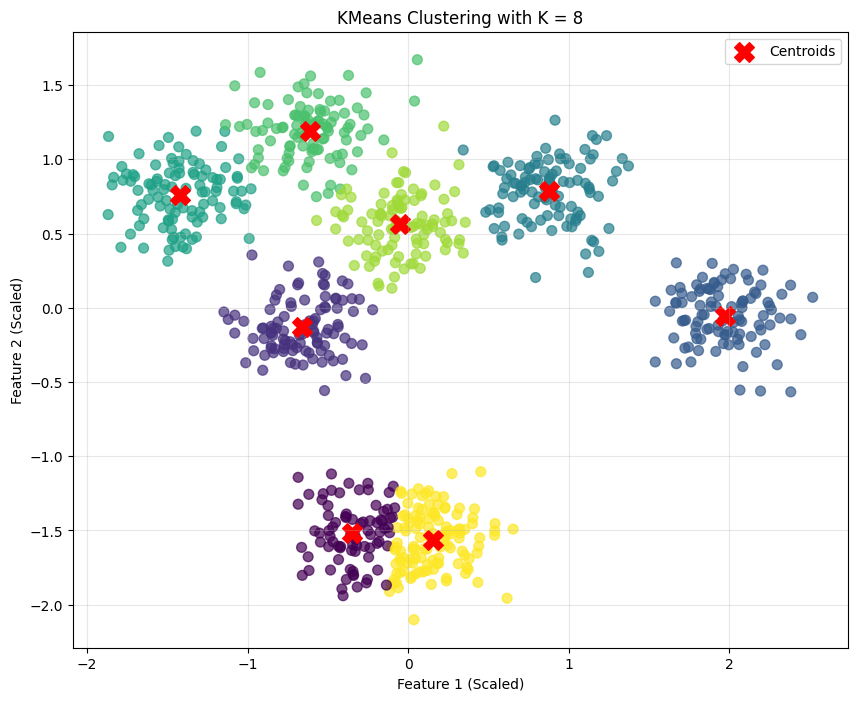

In [11]:
# Apply KMeans with the chosen optimal K (e.g., K=7)
optimal_k = 8
final_km = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
final_labels = final_km.fit_predict(x)
final_centroids = final_km.cluster_centers_

# Visualize the clusters
plt.figure(figsize=(10, 8))
plt.scatter(x[:, 0], x[:, 1], c=final_labels, cmap='viridis', s=50, alpha=0.7)
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title(f'KMeans Clustering with K = {optimal_k}')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

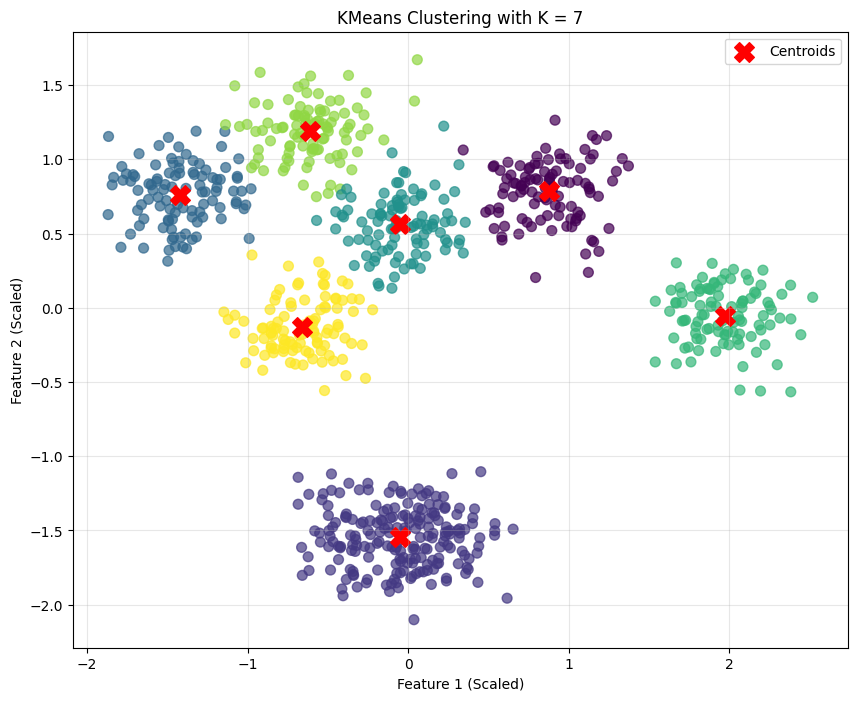

In [12]:
optimal_k = 7
final_km = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
final_labels = final_km.fit_predict(x)
final_centroids = final_km.cluster_centers_

# Visualize the clusters
plt.figure(figsize=(10, 8))
plt.scatter(x[:, 0], x[:, 1], c=final_labels, cmap='viridis', s=50, alpha=0.7)
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title(f'KMeans Clustering with K = {optimal_k}')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

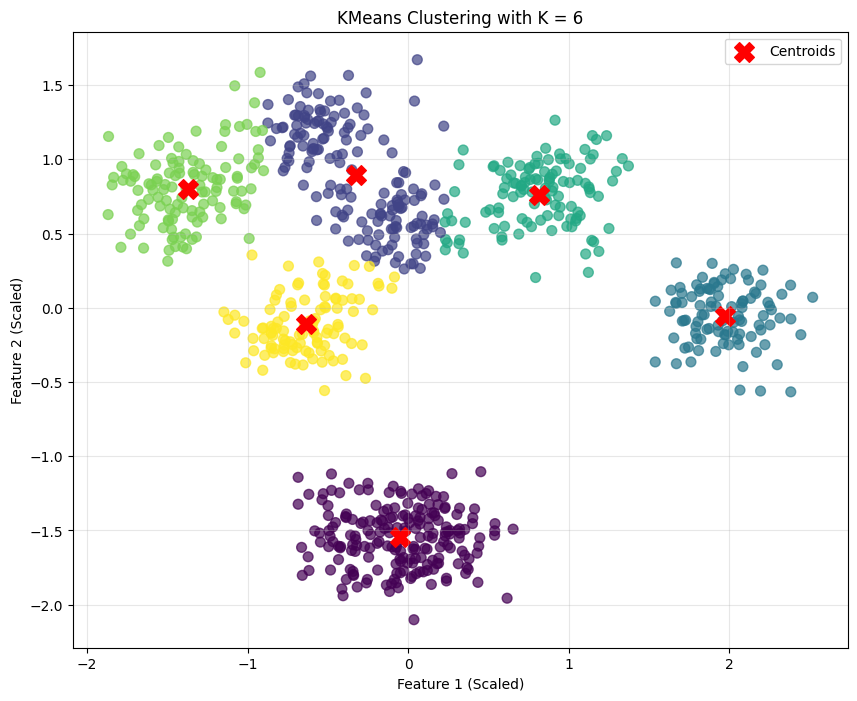

In [13]:
optimal_k = 6
final_km = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
final_labels = final_km.fit_predict(x)
final_centroids = final_km.cluster_centers_

# Visualize the clusters
plt.figure(figsize=(10, 8))
plt.scatter(x[:, 0], x[:, 1], c=final_labels, cmap='viridis', s=50, alpha=0.7)
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title(f'KMeans Clustering with K = {optimal_k}')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()